# Superstore Sales Analysis: Trends and Insights

**Objective:** In this notebook i'm presenting an exploratory data analysis (EDA) on the Superstore Sales dataset. The goal is to clean the data, identify key trends, and answer business questions related to sales performance over time, by product category, and by customer segment.

**Dataset:** `SuperstoreSalesDataset.csv`

**Tools Used:** Python, Pandas, Matplotlib, Seaborn

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set seaborn style for professional-looking plots
sns.set_style("whitegrid")

## 2. Load Data

Loading the dataset from the CSV file into a Pandas DataFrame and this will display the first few rows to understand its structure of the data.

In [49]:
df = pd.read_csv('SuperstoreSalesDataset.csv')

# Display the first few rows of the dataframe
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


## 3. Data Cleaning & Preparation

In this section, i am inspect the data for missing values, check data types, and handle any inconsistencies to prepare it for analysis.

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

### 3.1 Check Data Info and Missing Values

Use `.info()` to get a summary of the DataFrame, including data types and non-null counts.

In [50]:
# this will check for missing values in each cloumn
df.isnull().sum() 

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64

### 3.2 Handle Missing Values

Here i am fill the missing `Postal Code` values. Using '00000'. 

In [13]:
# Fill missing Postal Codes with 0 (or better, use a string)
df['Postal Code'] = df['Postal Code'].fillna('00000')

Verify missing values.

In [14]:
# again checking for missing values
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
dtype: int64

### 3.3 Convert Data Types

Converting `Order Date` and `Ship Date` from object (string) type to datetime objects for time-series analysis.

In [16]:
#now lets convert the 'Order Date' and 'Ship Date' columns to datetime format

df['Order Date'] = pd.to_datetime(df['Order Date'], format='%d/%m/%Y')
df['Ship Date'] = pd.to_datetime(df['Ship Date'], format='%d/%m/%Y')

### 3.4 Drop Unnecessary Columns

There is some unnecessary columns but im only removing `Row ID`.

In [17]:
# i'm droping columns which is unnecessary for analysis
df.drop(columns='Row ID', inplace=True)

### 3.5 Check for Duplicates

In [23]:
#checking for duplicates values in the databse;
df.duplicated().sum()

# Verify changes
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 17 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Order ID       9800 non-null   object        
 1   Order Date     9800 non-null   datetime64[ns]
 2   Ship Date      9800 non-null   datetime64[ns]
 3   Ship Mode      9800 non-null   object        
 4   Customer ID    9800 non-null   object        
 5   Customer Name  9800 non-null   object        
 6   Segment        9800 non-null   object        
 7   Country        9800 non-null   object        
 8   City           9800 non-null   object        
 9   State          9800 non-null   object        
 10  Postal Code    9800 non-null   float64       
 11  Region         9800 non-null   object        
 12  Product ID     9800 non-null   object        
 13  Category       9800 non-null   object        
 14  Sub-Category   9800 non-null   object        
 15  Product Name   9800 n

## 4. Exploratory Data Analysis (EDA)

Explore the data to understand identify patterns, and get initial insights.

### 4.1 Summary Statistics

`df.describe()` display the descriptive statistics for numerical columns.

In [27]:
df.describe()



,Order Date,Ship Date,Postal Code,Sales
count,9800,9800,9800.000000,9800.000000
mean,2017-05-01 05:13:51.673469440,2017-05-05 04:17:52.653061120,55211.280918,230.769059
min,2015-01-03 00:00:00,2015-01-07 00:00:00,0.000000,0.444000
25%,2016-05-24 00:00:00,2016-05-27 18:00:00,23223.000000,17.248000
50%,2017-06-26 00:00:00,2017-06-29 00:00:00,57551.000000,54.490000
75%,2018-05-15 00:00:00,2018-05-19 00:00:00,90008.000000,210.605000
max,2018-12-30 00:00:00,2019-01-05 00:00:00,99301.000000,22638.480000
std,NaN,NaN,32076.677954,626.651875


### 4.2 Categorical Variable Distributions

In [28]:
df['Category'].value_counts()


Category
Office Supplies    5909
Furniture          2078
Technology         1813
Name: count, dtype: int64

In [29]:
df['Segment'].value_counts()

Segment
Consumer       5101
Corporate      2953
Home Office    1746
Name: count, dtype: int64

In [30]:
df['Region'].value_counts()

Region
West       3140
East       2785
Central    2277
South      1598
Name: count, dtype: int64

### 4.3 Sales Distribution Visualization

Visualize the distribution of the `Sales` amount.

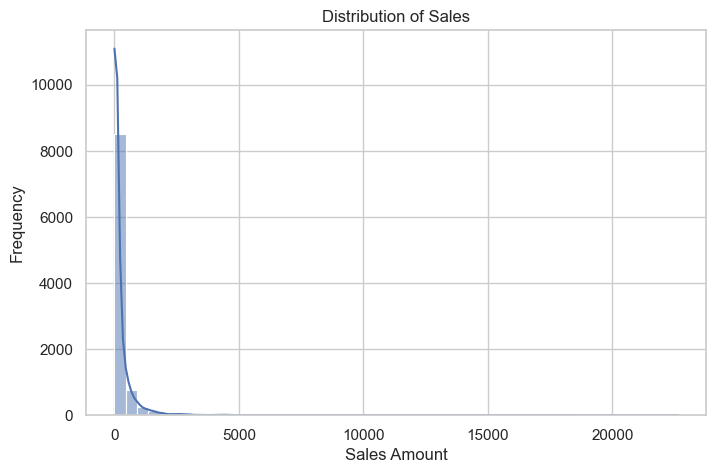

In [53]:
# ploting a quick histogram of sales to check distribution
plt.figure(figsize=(8, 5))
sns.histplot(df['Sales'], bins=50, kde=True)
plt.title('Distribution of Sales')
plt.xlabel('Sales Amount')
plt.ylabel('Frequency')
plt.show()

## 5. Analysis & Visualization - Answering Key Questions

### Question 1: What are the sales trends over time?


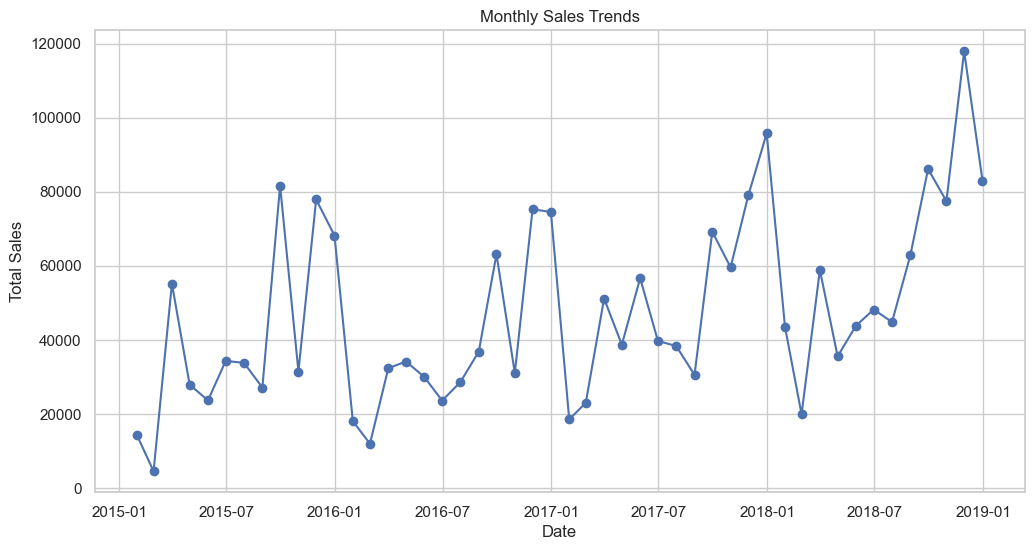

In [61]:
# Ensure 'Order Date' is datetime before setting as index
df_time = df.copy()
df_time['Order Date'] = pd.to_datetime(df_time['Order Date'], format='%d/%m/%Y')
df_time = df_time.set_index('Order Date')

# Resample to monthly sales data
monthly_sales = df_time['Sales'].resample('ME').sum()

# Plot line chart of monthly sales 
plt.figure(figsize=(12, 6))
plt.plot(monthly_sales.index, monthly_sales.values, marker='o')
plt.title('Monthly Sales Trends')
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.grid(True)
plt.show()

**Insight:** The monthly sales trend shows seasonality, with peaks typically occurring towards the end of the year (November/December) and troughs in the earlier months (like February). There might also be an overall upward trend over the years.

### Question 2: Which product categories generate the most sales?


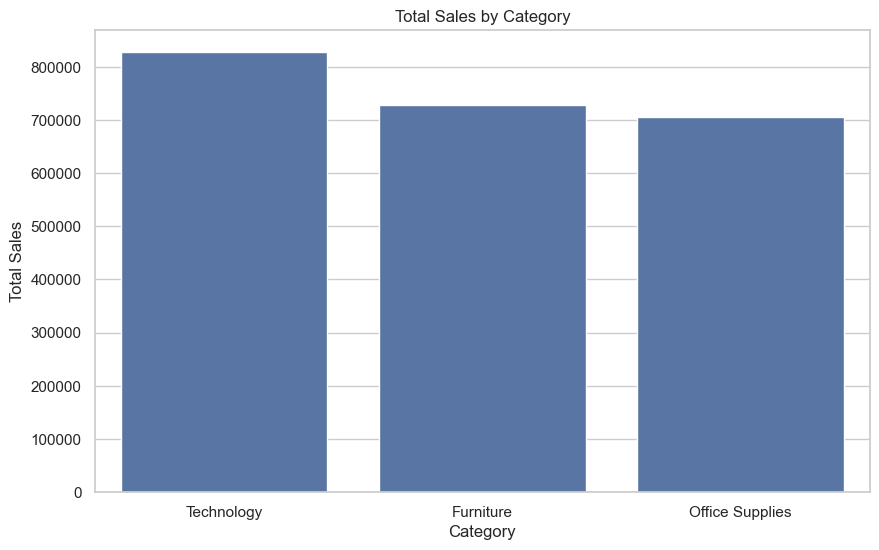

In [42]:
# Group by Category and calculate sum of Sales
category_stats = df.groupby('Category')[['Sales']].sum().reset_index()

# Sorting data by Sales descending
category_stats = category_stats.sort_values('Sales', ascending=False)

# Plotting bar chart for Sales by Category
plt.figure(figsize=(10, 6))
sns.barplot(x='Category', y='Sales', data=category_stats)
plt.title('Total Sales by Category')
plt.xlabel('Category')
plt.ylabel('Total Sales')
plt.show()



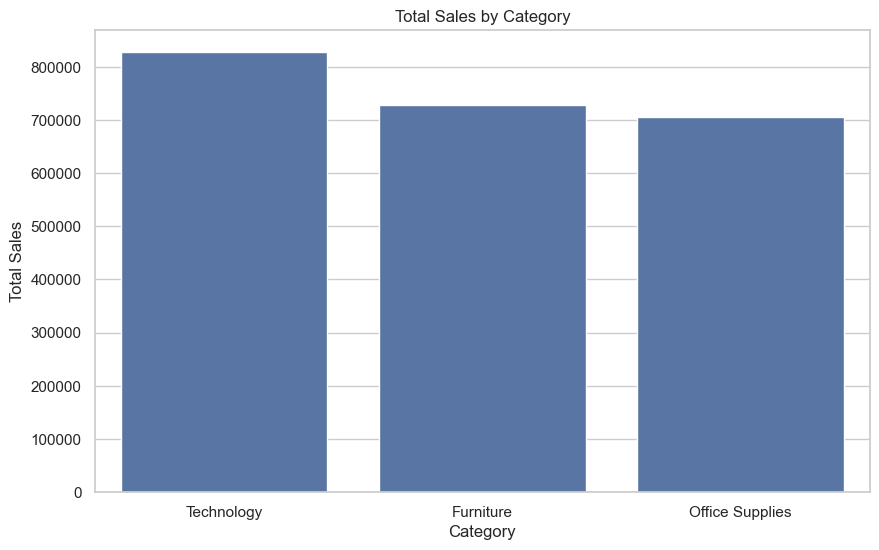

In [45]:
# Plot bar chart for Sales by Category using category_stats
plt.figure(figsize=(10, 6))
sns.barplot(x='Category', y='Sales', data=category_stats)
plt.title('Total Sales by Category')
plt.xlabel('Category')
plt.ylabel('Total Sales')
plt.show()

**Insight:** Technology generates the highest total sales, followed closely by Furniture. Office Supplies contributes the least to total sales revenue among the three main categories.

### Question 3: How do sales vary by customer segment?

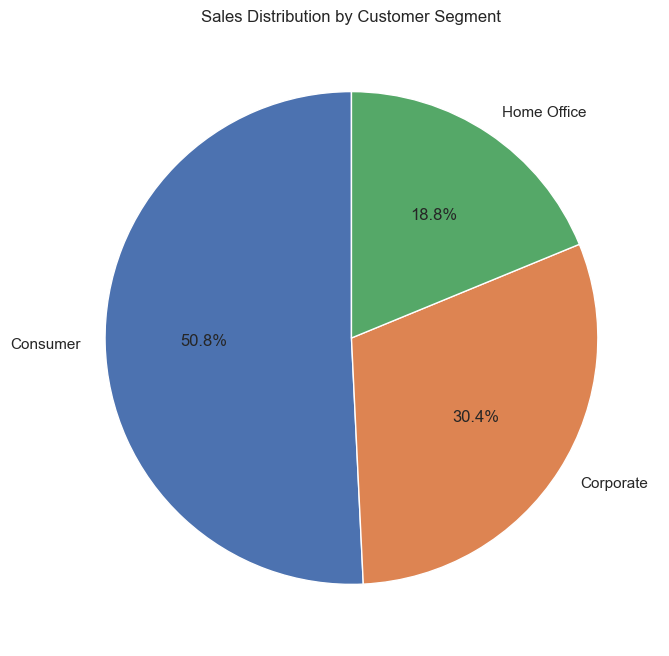

In [46]:
# Group by Segment and calculate sum of Sales
segment_sales = df.groupby('Segment')['Sales'].sum().reset_index()

# Plot pie chart
plt.figure(figsize=(8, 8))
plt.pie(segment_sales['Sales'], labels=segment_sales['Segment'], autopct='%1.1f%%', startangle=90)
plt.title('Sales Distribution by Customer Segment')
plt.show()

**Insight:** The Consumer segment accounts for the largest share of sales (approximately half), followed by the Corporate segment. The Home Office segment contributes the smallest portion.

## 6. Conclusion

This analysis provided several key insights into the Superstore sales data:

* **Sales Trend:** Sales exhibit clear seasonality, generally peaking late in the year.
* **Category Performance:** Technology and Furniture are the dominant categories in terms of sales revenue.
* **Segment Contribution:** The Consumer segment is the primary driver of sales, contributing roughly 50% of the total.

These findings are highlited the important areas of the business. Further analysis could done into profitability by category/segment, regional performance, or specific product trends.